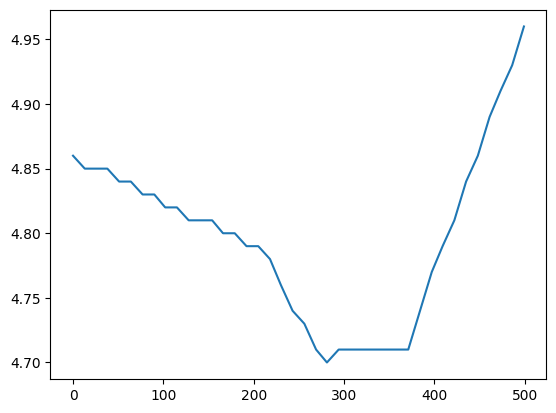

[[-5.03650490e+02 -2.47516727e+05  1.22898610e+06]]
Mittelpunkt = (251.8252447945881,123758.3635393651)
Radius = 123753.6543937084
positiv gekrümmt


In [7]:
import numpy as np
from math import sqrt,sin,pi
import matplotlib.pyplot as plt

#betrachtet Kruemmung entlang yAchse

l = 1100
b = 360
t = 3.6
step = 40

"""
wollen längs der x-Achse, auf Höhe von y/2, also egl b/2y, die Krümmung analysieren 
wir bilden also einen Array mit (x,z) Werten, machen ein Circle-Fitting und analysieren die krümmung abhängig davon ob der erhaltene Kreismittelpunkt oberhalb der platte oder unterhalb liegt
"""

# aus xyz-File

filename_messwerte = f"{t}mm_messwerte.xyz"
data_messwerte = np.loadtxt(filename_messwerte)

array100 = np.full(1600,100)

x_SW = data_messwerte[:,0]
y_SW = data_messwerte[:,1]
z_SW = data_messwerte[:,2] - array100

YstepMitte = round((step+1)/2)      # breite/2, auf mittlerer höhe
# Start_index = step*(Ystep_mitte-1)

y_Werte = [y_SW[YstepMitte+i*step] for i in range(step)]        
z_Werte = [z_SW[YstepMitte+i*step] for i in range(step)]


# selbst generierte Werte
"""
def f(x):
    return -10*sin(2*pi*x/l)

x_Werte = np.linspace(0,l,step)
z_Werte = [f(x) for x in x_Werte]
"""

plt.plot(y_Werte,z_Werte)
plt.show()


# region CIRCLE FITTING ALGORITHM
"""
- Gleichung:
    x²+y²+Dx+Ey+F = r² 
- umwandeln zu:
    Dx+Ey+F = -(x²+y²)
    -> also LGS bzgl (D,E,F)
D = -2x_c
E = -2y_c
F = x_c² + y_c² -r²

- erhalten Mittelpunkt und Radius eines Kreises:
x_c = -D/2
y_c = -E/2
r = sqrt(F-(x_c²+y_c²))
"""

yz_Array = [ [float(y),float(z)] for y,z in zip(y_Werte,z_Werte) ]      # (x,z) entlang der linie

A_mat = np.matrix([   [entry[0],entry[1],1] for entry in yz_Array    ])        #ist bereits transponierte Matrix
AT_mat = np.matrix.transpose(A_mat)
b_vec = [-(x**2+z**2) for (x,z) in yz_Array]


# zu lösen: (AT*A)x = AT*b <=> x = (AT*A)^(-1)*AT*b
AT_A_mat = AT_mat * A_mat
AT_A_invers = np.linalg.inv(AT_A_mat)
result = AT_A_invers * AT_mat @ b_vec

print(result)        # x = [D,E,F]

D = result[0,0]
E = result[0,1]
F = result[0,2]

# endregion

X_Mittelpunkt = -D/2
Z_Mittelpunkt = -E/2
Radius = sqrt( ( X_Mittelpunkt**2 + Z_Mittelpunkt**2 ) - F )

print(f"Mittelpunkt = ({X_Mittelpunkt},{Z_Mittelpunkt})\nRadius = {Radius}")

# daraus analysieren, ob positiv oder negativ gekrümmt
tol = 10e-11        # bei sinus-kurve ab 10e-12 meinte negativ gekrümmt, also ab dieser toleranz falsch
if Z_Mittelpunkt >= tol:
    print("positiv gekrümmt")

elif Z_Mittelpunkt <= -tol:
    print("negativ gekrümmt")
else:
    print("keine Aussage möglich")
